In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, MeanShift
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

# ------------------- 1. LOAD & CLEAN DATA -------------------
df = pd.read_csv('data/marketing_campaign.csv', sep='\t')   # ← important: tab separator

# Basic cleaning
df = df.dropna(subset=['Income'])
df['Age'] = 2026 - df['Year_Birth']
df['Total_Spent'] = df[['MntWines', 'MntFruits', 'MntMeatProducts', 
                        'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)
df['Total_Purchases'] = df[['NumDealsPurchases', 'NumWebPurchases', 
                            'NumCatalogPurchases', 'NumStorePurchases']].sum(axis=1)

# Drop unnecessary columns
df = df.drop(columns=['ID', 'Year_Birth', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue'])

print(f"Dataset shape after cleaning: {df.shape}")

Dataset shape after cleaning: (2216, 27)


In [4]:
# ------------------- 2. PREPROCESSING (The 3 steps you need) -------------------
categorical_cols = ['Education', 'Marital_Status']
numerical_cols = [col for col in df.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),           # ← SCALING
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)  # ← ENCODING
    ])

# Full pipeline with Dimensionality Reduction
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=8))                         # ← DIMENSIONALITY REDUCTION
])

X = pipeline.fit_transform(df)
print(f"Final shape after preprocessing: {X.shape}")

# Explained variance
print("Explained variance by 8 components:", 
      round(pipeline.named_steps['pca'].explained_variance_ratio_.sum() * 100, 2), "%")

Final shape after preprocessing: (2216, 8)
Explained variance by 8 components: 67.33 %


In [6]:
# ------------------- 3. CLUSTERING - Each member does one method -------------------

# Member 1: K-Means
print("\n=== Member 1: K-Means ===")
inertia = []
sil_scores = []
K_range = range(2, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X, kmeans.labels_))

best_k = K_range[np.argmax(sil_scores)]
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)
kmeans_sil = silhouette_score(X, kmeans_labels)
kmeans_db = davies_bouldin_score(X, kmeans_labels)


=== Member 1: K-Means ===


In [7]:
# Member 2: DBSCAN
print("\n=== Member 2: DBSCAN ===")
dbscan = DBSCAN(eps=1.2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)
dbscan_sil = silhouette_score(X, dbscan_labels) if len(set(dbscan_labels)) > 1 else -1
dbscan_db = davies_bouldin_score(X, dbscan_labels)


=== Member 2: DBSCAN ===


In [8]:
# Member 3: MeanShift
print("\n=== Member 3: MeanShift ===")
meanshift = MeanShift()
meanshift_labels = meanshift.fit_predict(X)
meanshift_sil = silhouette_score(X, meanshift_labels) if len(set(meanshift_labels)) > 1 else -1
meanshift_db = davies_bouldin_score(X, meanshift_labels)


=== Member 3: MeanShift ===



=== Comparison Results ===
      Method          Optimal Params  Silhouette Score  Davies-Bouldin
0    K-Means                     K=2             0.361           1.203
1     DBSCAN  eps=1.2, min_samples=5            -0.228           1.537
2  MeanShift                    auto             0.313           0.963


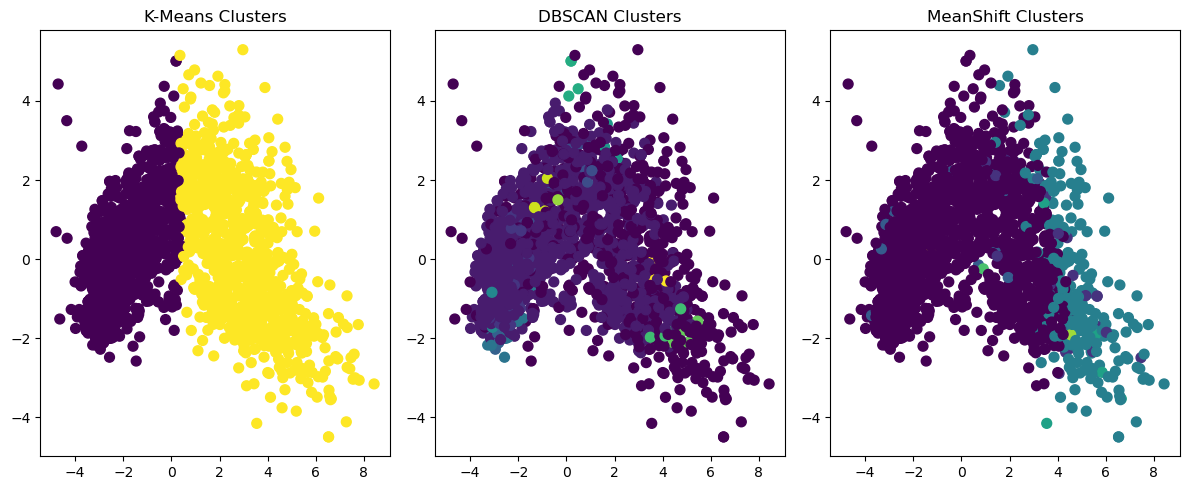

In [9]:
# ------------------- 4. COMPARISON TABLE (Part f) -------------------
results = pd.DataFrame({
    'Method': ['K-Means', 'DBSCAN', 'MeanShift'],
    'Optimal Params': [f'K={best_k}', 'eps=1.2, min_samples=5', 'auto'],
    'Silhouette Score': [round(kmeans_sil, 3), round(dbscan_sil, 3), round(meanshift_sil, 3)],
    'Davies-Bouldin': [round(kmeans_db, 3), round(dbscan_db, 3), round(meanshift_db, 3)]
})
print("\n=== Comparison Results ===")
print(results)

# ------------------- 5. VISUALISATION (2D PCA) -------------------
pca_2d = PCA(n_components=2).fit_transform(X)
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.scatter(pca_2d[:, 0], pca_2d[:, 1], c=kmeans_labels, cmap='viridis', s=50)
plt.title('K-Means Clusters')

plt.subplot(1, 3, 2)
plt.scatter(pca_2d[:, 0], pca_2d[:, 1], c=dbscan_labels, cmap='viridis', s=50)
plt.title('DBSCAN Clusters')

plt.subplot(1, 3, 3)
plt.scatter(pca_2d[:, 0], pca_2d[:, 1], c=meanshift_labels, cmap='viridis', s=50)
plt.title('MeanShift Clusters')

plt.tight_layout()
plt.show()